In [13]:
# notebook magics
# inline/notebook/interactive
%matplotlib notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# import utilities and plotting
from argparse import Namespace
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
# make figures higher resolution (larger)
plt.rcParams['figure.dpi'] = 150
# A decent backend for animations
plt.rcParams["animation.html"] = "jshtml"
# let 'em get big
plt.rcParams["animation.embed_limit"] = 100  # MB

# import our code that we need
import os, sys 
sys.path.append(os.path.abspath("lib")) # N.B: NB needs this line to run locally!!
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("notebook-2D.ipynb"), '..', 'lib')))

import linalg_helper as lib
from plotting import plotpotential3D_ps, plotpsi2D
import mem_polar_cpu_etf as fcm
#import fixed_center_of_mass_exact_2D as fsm
from davidson import get_davidson_mem
from debug import timer_ctx
from constants import *

# don't use too many cores
from threadpoolctl import ThreadpoolController
threadctl = ThreadpoolController()
threadctl.limit(limits=16)

ImportError: cannot import name 'plotpotential3D_ps' from 'plotting' (/home/mb3835/ps-model-exact/lib/plotting.py)

In [18]:
import mem_polar_cpu_etf as fcm

In [19]:
# set up the calculation
args = Namespace(
    M_1 = 2e3, M_2 = 2e3,
    #M_1 = 1, M_2 = 1,
    g_1 = 1.0, g_2 = 1.0,
    #NR = 6, #6, 30
    #Nr = 50,
    #Ng = 40, # 80
    #NR = 20,
    #Nr = 36,
    #Ng = 34,
    NR = 50,
    Nr = 40,
    Ng = 40,
    Np = 40,
    J = 0,
    #extent = np.array((1/51, 4, 4)),
    #extent = np.array((1/51, .7, .7)),
    #funcparams=dict(dv=0.5, G=1, p=1),
    potential = 'borgis',
    preconditioner='BO', t=16,
    #extent = (0.94,1.89,10.6)   # defaults are (2,4,5), but they should be selected better (R_min, R_max, r_max)
)

# build the terms in the Hamiltonian
H = fcm.Hamiltonian(args)

levels = np.linspace(np.min(H.Vgrid), np.min(H.Vgrid) + 0.15*4, 16) # 0.15 a.u. ~4 eV range
print(levels)

Waring: All masses scaled to AMU for borgis!
Potential: borgis
r_max 5.2
R_range [4.2 5.2]
unscaled coords: [4.2 5.2] 5.2
  scaled coords: [4.2 5.2] 5.2
[-0.05375252 -0.01375252  0.02624748  0.06624748  0.10624748  0.14624748
  0.18624748  0.22624748  0.26624748  0.30624748  0.34624748  0.38624748
  0.42624748  0.46624748  0.50624748  0.54624748]


In [20]:
from IPython.display import HTML
import matplotlib.animation as animation

In [31]:
from plotting import plot3D_test1

<IPython.core.display.Javascript object>


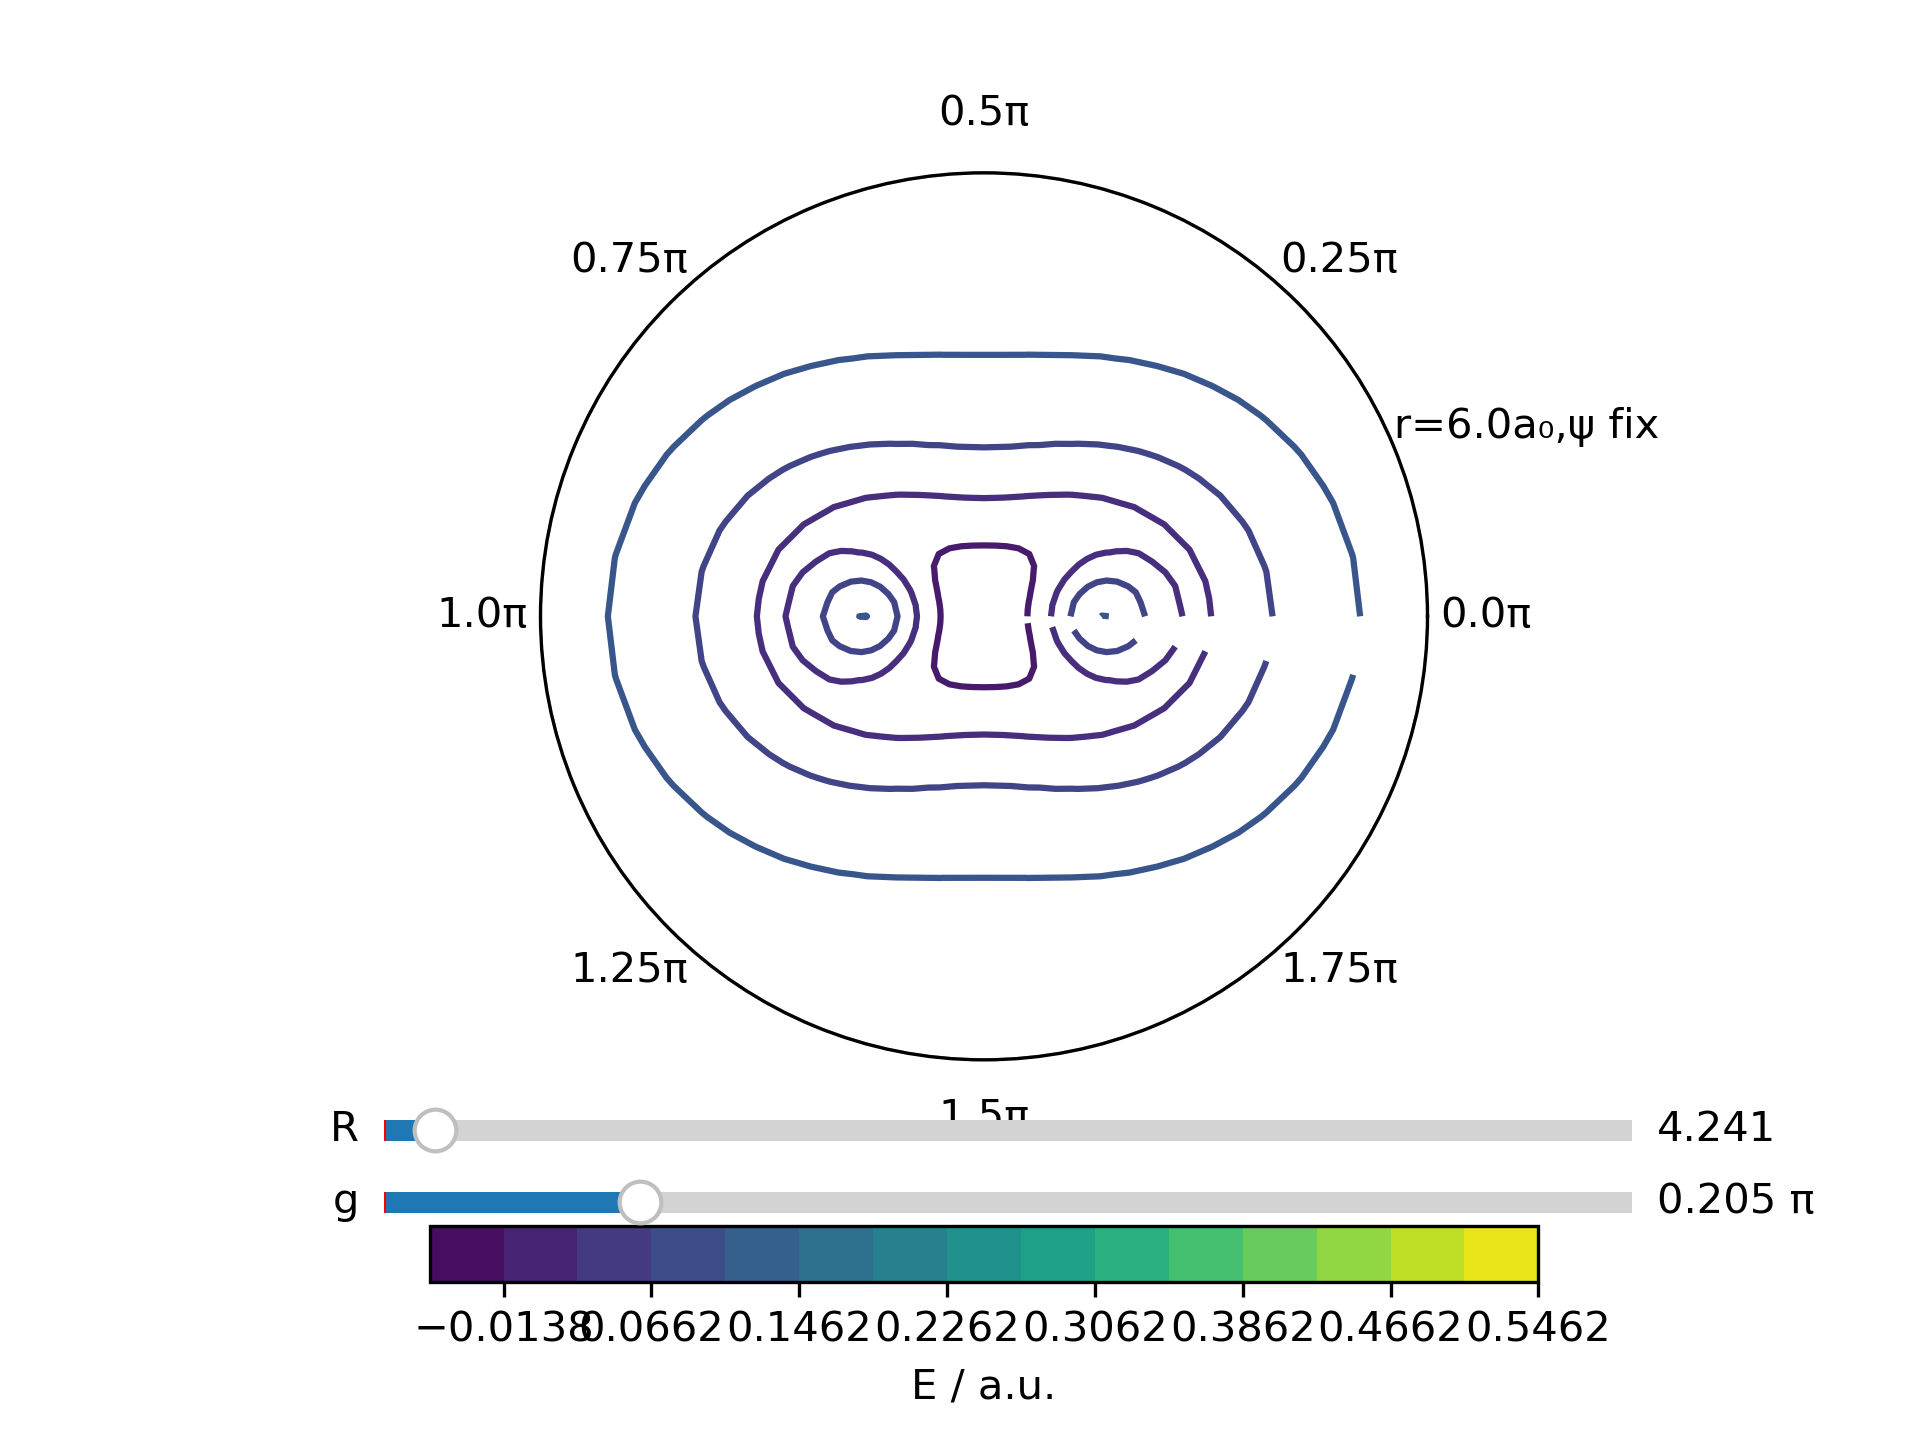

p (40,)
g (40,)
V (40, 40)


None

In [32]:
display(plot3D_test1(H,args.Ng,args.Np,levels))

In [38]:
(H.p)

array([0.        , 0.16110732, 0.32221463, 0.48332195, 0.64442926,
       0.80553658, 0.96664389, 1.12775121, 1.28885852, 1.44996584,
       1.61107316, 1.77218047, 1.93328779, 2.0943951 , 2.25550242,
       2.41660973, 2.57771705, 2.73882436, 2.89993168, 3.061039  ,
       3.22214631, 3.38325363, 3.54436094, 3.70546826, 3.86657557,
       4.02768289, 4.1887902 , 4.34989752, 4.51100484, 4.67211215,
       4.83321947, 4.99432678, 5.1554341 , 5.31654141, 5.47764873,
       5.63875604, 5.79986336, 5.96097068, 6.12207799, 6.28318531])

In [47]:
H.p/(np.pi)

array([0.        , 0.05128205, 0.1025641 , 0.15384615, 0.20512821,
       0.25641026, 0.30769231, 0.35897436, 0.41025641, 0.46153846,
       0.51282051, 0.56410256, 0.61538462, 0.66666667, 0.71794872,
       0.76923077, 0.82051282, 0.87179487, 0.92307692, 0.97435897,
       1.02564103, 1.07692308, 1.12820513, 1.17948718, 1.23076923,
       1.28205128, 1.33333333, 1.38461538, 1.43589744, 1.48717949,
       1.53846154, 1.58974359, 1.64102564, 1.69230769, 1.74358974,
       1.79487179, 1.84615385, 1.8974359 , 1.94871795, 2.        ])

<IPython.core.display.Javascript object>


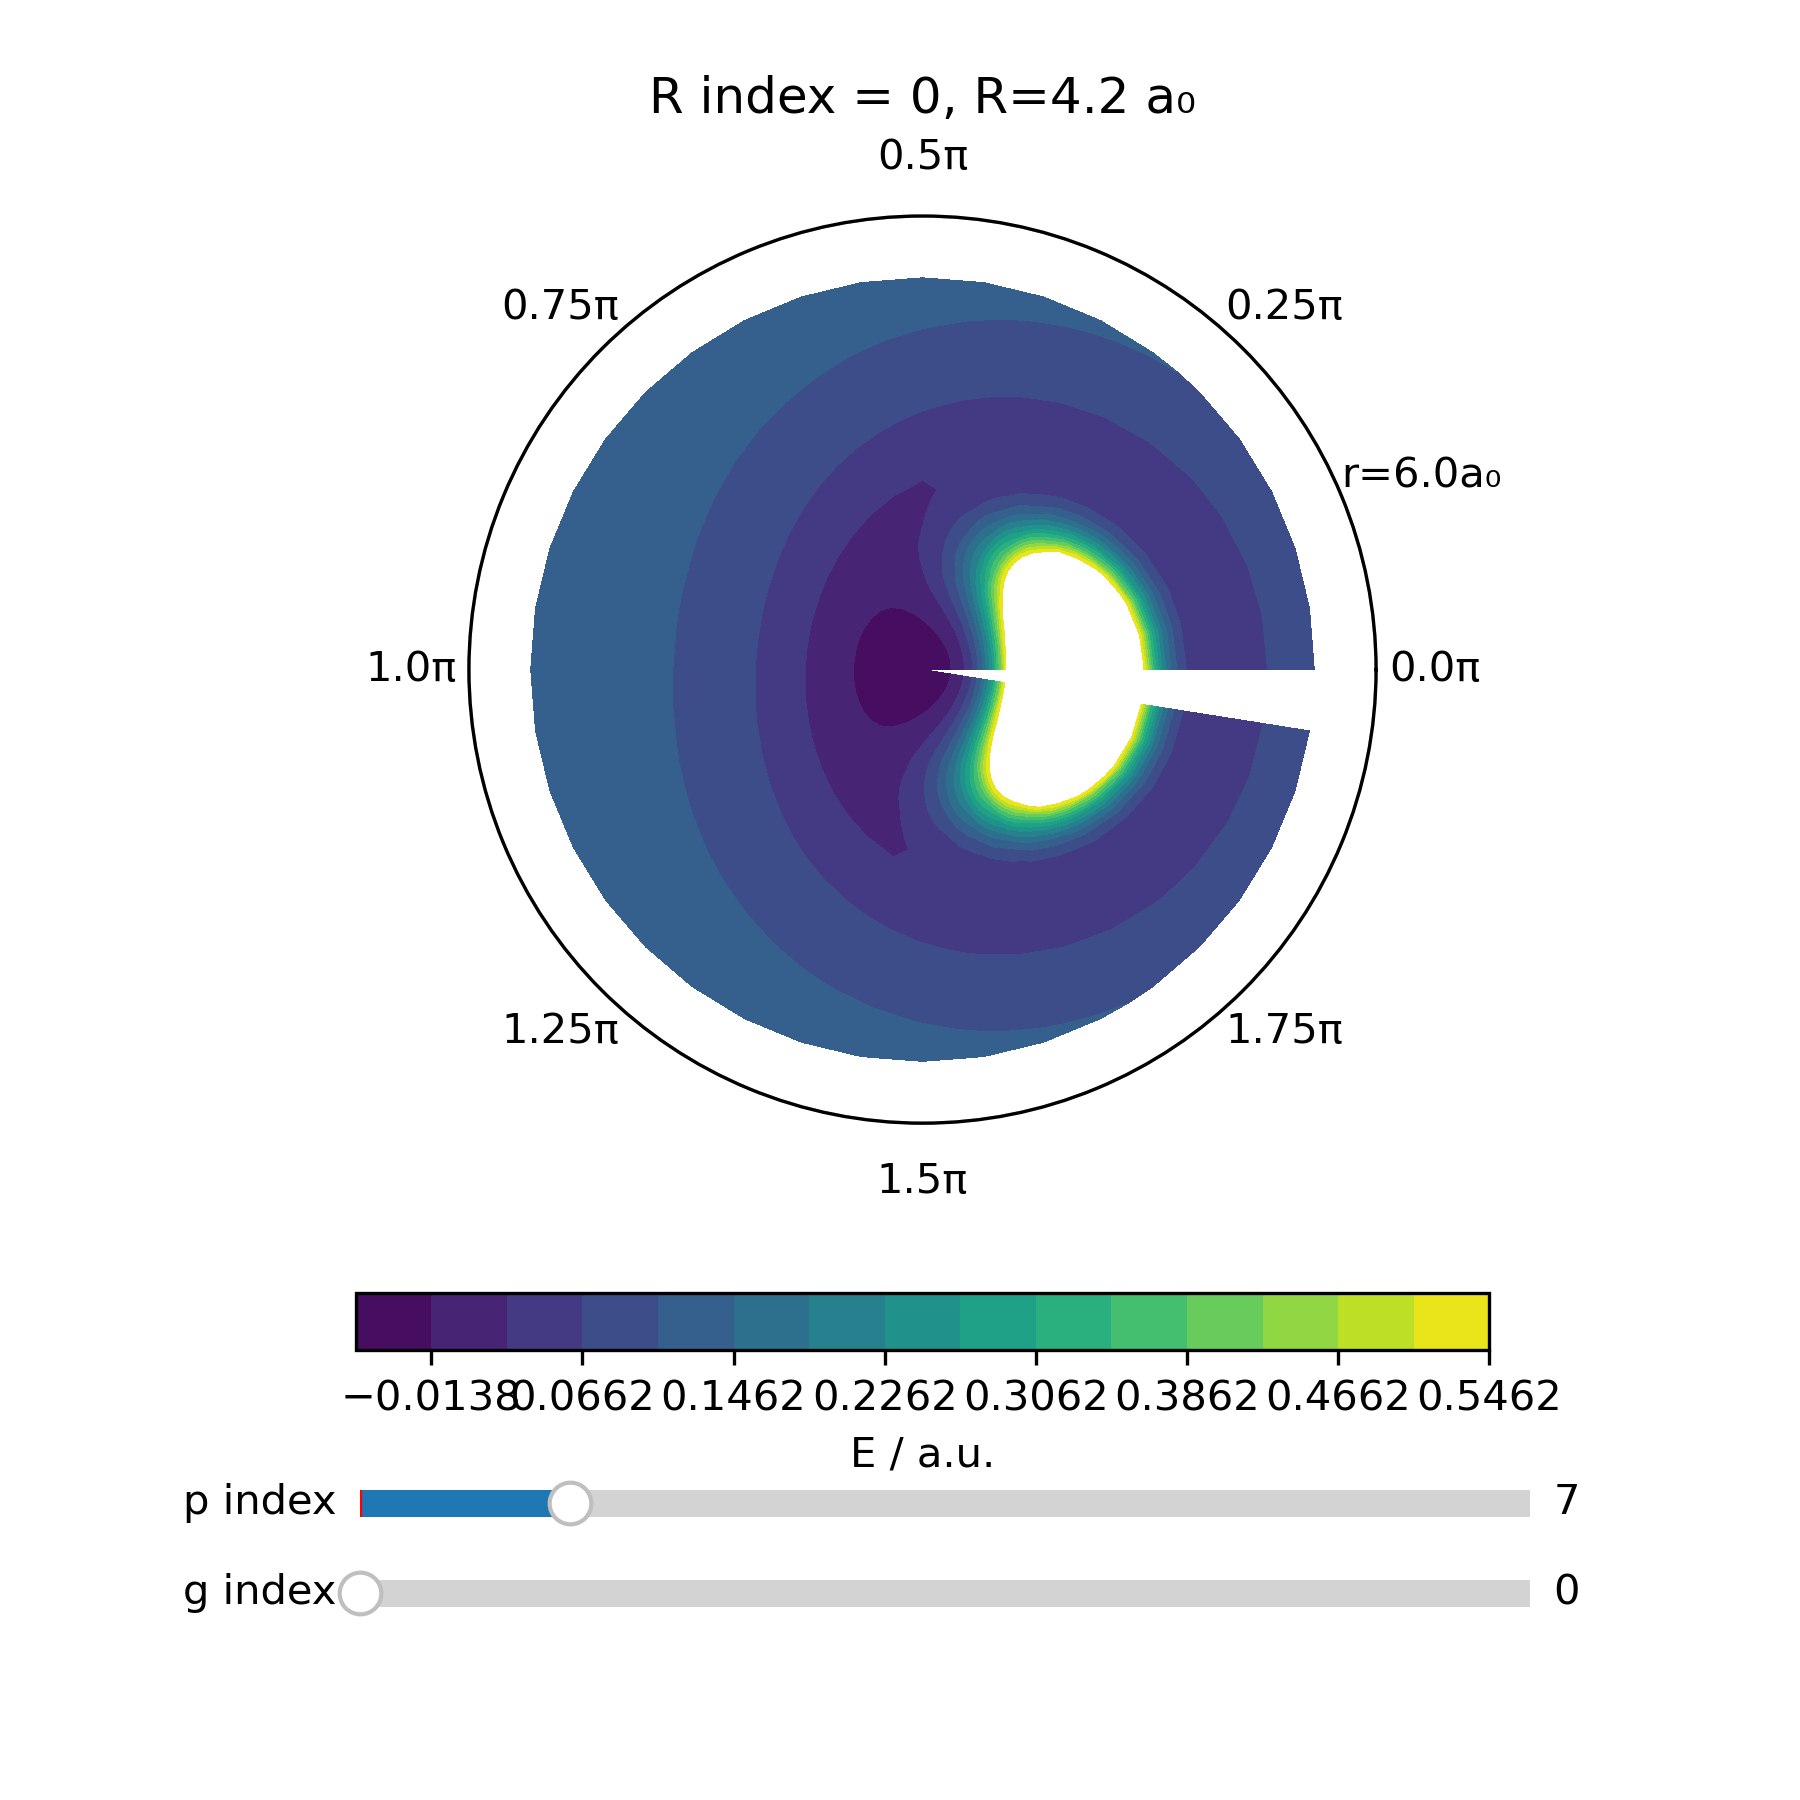

In [30]:
display(plot3D_animate(H,args.Ng,args.Np,levels))

In [56]:
a = np.array([1,2,3,4,5])
a[-1:]

array([5])